In [27]:
from PIL import Image
image_colored = Image.open("/content/drive/MyDrive/AI-ML/Data/eye.png")
display ( image_colored )

Output hidden; open in https://colab.research.google.com to view.

Getting Shape and Size of an Image Using PIL

In [18]:
print ( " Image Format : " , image_colored . format )
print ( " Image Size : " , image_colored . size )
print ( " Image Mode : " , image_colored . mode )

 Image Format :  PNG
 Image Size :  (1258, 836)
 Image Mode :  RGBA


In [19]:
width , height = image_colored . size
channels = len( image_colored . getbands () ) # For RGB , it will be 3
print ( f" Image shape (RGB): ({ height } , { width } , { channels})")
image_size_colored = width * height *3
print ( f" Image size (RGB): { image_size_colored }")

 Image shape (RGB): (836 , 1258 , 4)
 Image size (RGB): 3155064


Converting Image to NumPy Array.

In [21]:
import numpy as np
image_array_colored = np . array ( image_colored )
# Display the shape of the NumPy array (height , width ,channels )
print (" Shape of the image array :", image_array_colored.shape )

 Shape of the image array : (836, 1258, 4)


Extracting Colored Channels with NumPy Array.

In [22]:
# Convert the Pillow image to a NumPy array
image_array_colored = np . array ( image_colored )
# Display the shape of the NumPy array (height , width , channels )
print (" Shape of the image array :", image_array_colored . shape)
#For Red Channels
red_channel = image_array_colored [: , : , 0] # Red channel
print ( red_channel )
display ( red_channel )
# For Green Channels
green_channel = image_array_colored [: , : , 0] # Green channel
print ( green_channel )
display ( green_channel )

 Shape of the image array : (836, 1258, 4)
[[ 12  12  12 ... 219 223 229]
 [ 12  12  12 ... 225 232 238]
 [ 12  12  12 ... 234 241 246]
 ...
 [  7   7   7 ... 205 193 178]
 [  6   5   5 ... 198 187 174]
 [  6   5   5 ... 193 183 171]]


array([[ 12,  12,  12, ..., 219, 223, 229],
       [ 12,  12,  12, ..., 225, 232, 238],
       [ 12,  12,  12, ..., 234, 241, 246],
       ...,
       [  7,   7,   7, ..., 205, 193, 178],
       [  6,   5,   5, ..., 198, 187, 174],
       [  6,   5,   5, ..., 193, 183, 171]], dtype=uint8)

[[ 12  12  12 ... 219 223 229]
 [ 12  12  12 ... 225 232 238]
 [ 12  12  12 ... 234 241 246]
 ...
 [  7   7   7 ... 205 193 178]
 [  6   5   5 ... 198 187 174]
 [  6   5   5 ... 193 183 171]]


array([[ 12,  12,  12, ..., 219, 223, 229],
       [ 12,  12,  12, ..., 225, 232, 238],
       [ 12,  12,  12, ..., 234, 241, 246],
       ...,
       [  7,   7,   7, ..., 205, 193, 178],
       [  6,   5,   5, ..., 198, 187, 174],
       [  6,   5,   5, ..., 193, 183, 171]], dtype=uint8)

Accessing individual channels

In [23]:
blue_channel = image_array_colored [: , : , 2] # Blue channel
print ( blue_channel )
display ( blue_channel )

[[  6   6   6 ...  61  66  70]
 [  6   6   6 ...  54  57  58]
 [  6   6   6 ...  54  54  51]
 ...
 [ 10  10  10 ... 159 159 156]
 [  9   8   8 ... 158 158 155]
 [  9   8   8 ... 158 158 154]]


array([[  6,   6,   6, ...,  61,  66,  70],
       [  6,   6,   6, ...,  54,  57,  58],
       [  6,   6,   6, ...,  54,  54,  51],
       ...,
       [ 10,  10,  10, ..., 159, 159, 156],
       [  9,   8,   8, ..., 158, 158, 155],
       [  9,   8,   8, ..., 158, 158, 154]], dtype=uint8)

In [30]:
r , g , b , a = image_colored.split()
# Display or further process the individual channels
display ( r )
display ( g )
display ( b )

Output hidden; open in https://colab.research.google.com to view.

Extracting Sub Images from an Image Array.

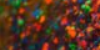

In [68]:
# Sample Implementation :
# Accessing a specific row - 100 th row
row_100 = image_array_colored [550 , : , :]
# Accessing a specific column - 50 th col
col_50 = image_array_colored [: , 150 , :]
# Accessing a specific pixel (row 10 , col 20)
pixel = image_array_colored [10 , 20 , :] # Gets RGB values at (10 ,20)
# Define the cropping box (left , upper , right , lower )
left = 150
upper = 50
right = 250
lower = 100
# Crop the image
cropped_image = image_colored . crop (( left , upper , right , lower ) )
# Display the cropped image
display ( cropped_image )

Saving NumPy Array to Image.

In [49]:
# Create a NumPy array (Here , we use a dummy array forillustration )
image_array = np . zeros ((100 , 100 , 3) , dtype = np . uint8 ) #Example : black image
3 # Convert the NumPy array back to a Pillow Image object
image_from_array = Image . fromarray ( image_array_colored )
5 # Display the image
image_from_array . show ()
display ( image_from_array )
7 # Optionally save the image to a file
image_from_array.save ("output_image.png")

Output hidden; open in https://colab.research.google.com to view.

# PCA for Image Compression. "With Eigen Value Decomposition"

Load and Prepare Image Data:

In [51]:
import numpy as np
import matplotlib . pyplot as plt
from PIL import Image
# Load image and convert to grayscale
image = Image . open ("/content/drive/MyDrive/AI-ML/Data/eye.png") . convert ("L")
# Convert to NumPy array
image_array = np . array ( image )
# Get image dimensions
height , width = image_array . shape
# Reshape the image into a 2D array where each row represents a row of pixels
# This allows PCA to process each row as an observation and find patterns across pixel intensities
data = image_array . reshape ( height , width )

Standardize the Data:

In [52]:
# Compute the mean of each column ( feature )
mean = np . mean ( data , axis =0)
# Subtract mean to center the data
centered_data = data - mean

Compute Covariance Matrix:

In [53]:
# Compute covariance matrix
cov_matrix = np . cov ( centered_data , rowvar = False )

Compute Eigenvalues & Eigenvectors:

In [54]:
# Compute eigenvalues and eigenvectors
eigenvalues , eigenvectors = np . linalg . eigh ( cov_matrix )
# Sort eigenvalues and corresponding eigenvectors in descending order
sorted_indices = np . argsort ( eigenvalues ) [:: -1]
eigenvalues = eigenvalues [ sorted_indices ]
eigenvectors = eigenvectors [: , sorted_indices ]

Picking the Principal Components:

Explained Variance :

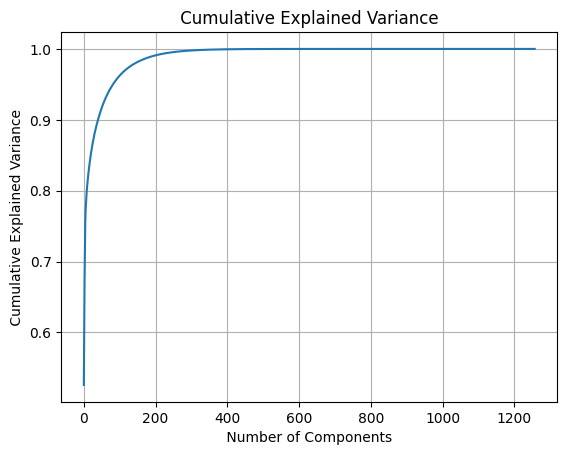

In [55]:
# Plot the explained variance ratio
explained_variance_ratio = eigenvalues / np .sum ( eigenvalues )
plt . plot ( np . cumsum ( explained_variance_ratio ) )
plt . title (" Cumulative Explained Variance ")
plt . xlabel (" Number of Components ")
plt . ylabel (" Cumulative Explained Variance ")
plt . grid ( True )
plt . show ()

Select Top k Principal Component :

In [56]:
k = 50 # Choose k principal components
components = eigenvectors [: , : k ]

Compress the Image :

In [59]:
# Project the data onto the principal components
compressed_data = np . dot ( centered_data , components )

Reconstruct (Decompress) the Image :

In [60]:
# Reconstruct the image from compressed data
decompressed_data = np . dot ( compressed_data , components . T ) + mean

Final Visualization:

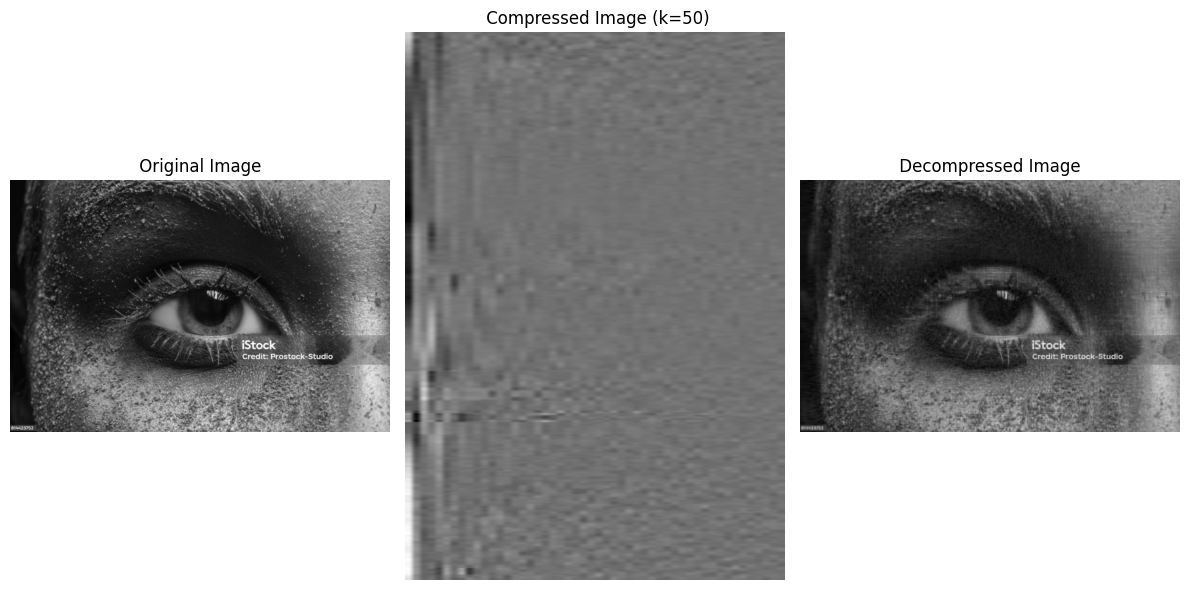

In [63]:
plt . figure ( figsize =(12 , 6) )
# Original Image
plt . subplot (1 , 3 , 1)
plt . imshow ( image_array , cmap ="gray")
plt . title (" Original Image ")
plt . axis ("off")
# Compressed Representation
plt . subplot (1 , 3 , 2)
plt . imshow ( compressed_data , cmap ="gray", aspect ="auto")
plt . title ( f" Compressed Image (k={k})")
plt . axis ("off")
# Decompressed Image
plt . subplot (1 , 3 , 3)
plt . imshow ( decompressed_data , cmap ="gray")
plt . title (" Decompressed Image ")
plt . axis ("off")
plt . tight_layout ()
plt . show ()